In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_visa_dataset.csv")
df.head()

,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days
0,Certified,2021-09-26,2021-10-01,H-1B,APPLICATIONS SUPPORT ANALYST/ADMINISTRATOR,Y,NJ,GA,92000.0,87485.0,5
1,Certified,2021-09-26,2021-10-01,H-1B,Designer,Y,MI,MI,56181.0,56181.0,5
2,Certified,2021-09-26,2021-10-01,H-1B,Data Analyst,Y,FL,MA,60000.0,59238.0,5
3,Certified,2021-09-26,2021-10-01,H-1B,Pharmaceutical Chemist,Y,MN,MN,56160.0,53851.0,5
4,Certified,2021-09-26,2021-10-01,H-1B,Senior Systems Analyst JC60,Y,TX,TN,70325.0,70325.0,5


In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 201025 entries, 0 to 201024
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CASE_STATUS            201025 non-null  object 
 1   RECEIVED_DATE          201025 non-null  object 
 2   DECISION_DATE          201025 non-null  object 
 3   VISA_CLASS             201025 non-null  object 
 4   JOB_TITLE              201025 non-null  object 
 5   FULL_TIME_POSITION     201025 non-null  object 
 6   EMPLOYER_STATE         201025 non-null  object 
 7   WORKSITE_STATE         201025 non-null  object 
 8   WAGE_RATE_OF_PAY_FROM  201025 non-null  float64
 9   PREVAILING_WAGE        201025 non-null  float64
 10  processing_days        201025 non-null  int64  
dtypes: float64(2), int64(1), object(8)
memory usage: 16.9+ MB


,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days
count,2.010250e+05,201025.000000,201025.000000
mean,1.138987e+05,97481.830408,24.190146
std,7.863341e+04,39818.240270,87.257473
min,1.125000e+01,7.250000,0.000000
25%,8.400000e+04,76856.000000,7.000000
50%,1.091220e+05,95555.000000,7.000000
75%,1.409200e+05,119933.000000,8.000000
max,1.950000e+07,810850.000000,888.000000


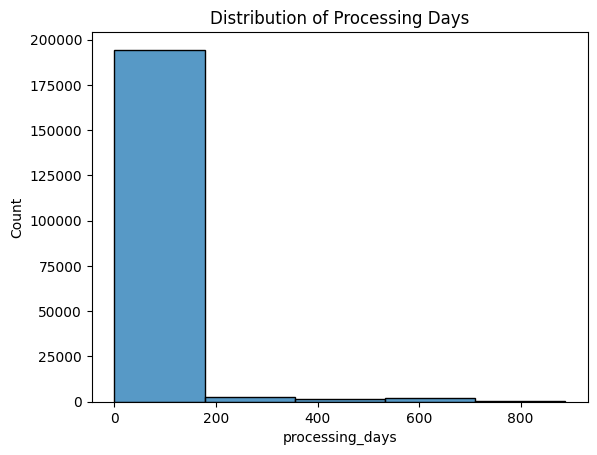

In [3]:
plt.figure()
sns.histplot(df['processing_days'], bins=5)

plt.title("Distribution of Processing Days")
plt.show()

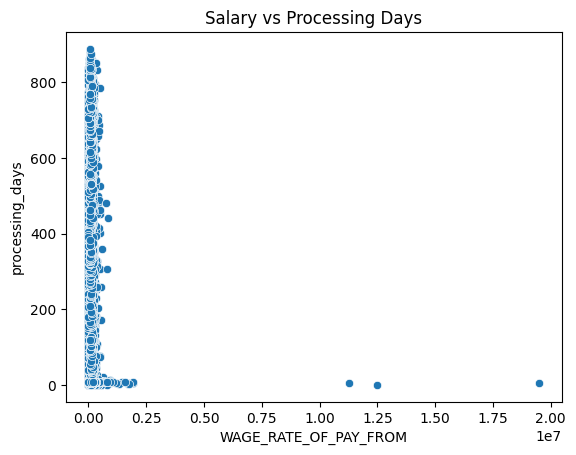

In [4]:
plt.figure()
sns.scatterplot(x='WAGE_RATE_OF_PAY_FROM', y='processing_days', data=df)

plt.title("Salary vs Processing Days")
plt.show()

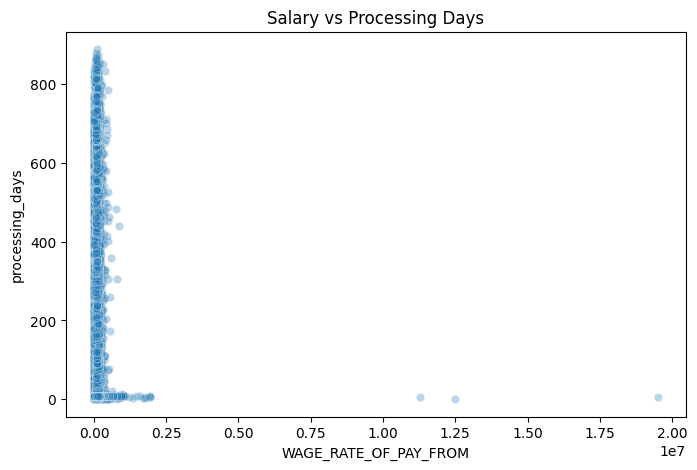

In [5]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='WAGE_RATE_OF_PAY_FROM',
    y='processing_days',
    data=df,
    alpha=0.3
)

plt.title("Salary vs Processing Days")
plt.show()

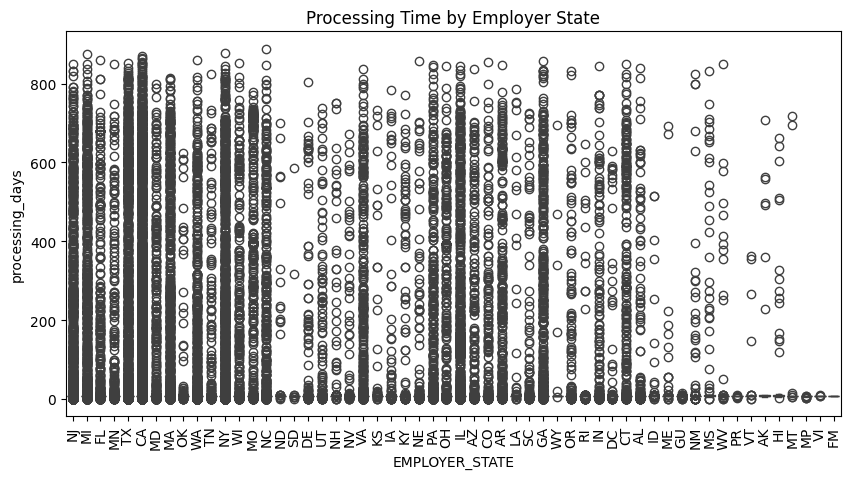

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(x='EMPLOYER_STATE', y='processing_days', data=df)

plt.xticks(rotation=90)

plt.title("Processing Time by Employer State")

plt.show()

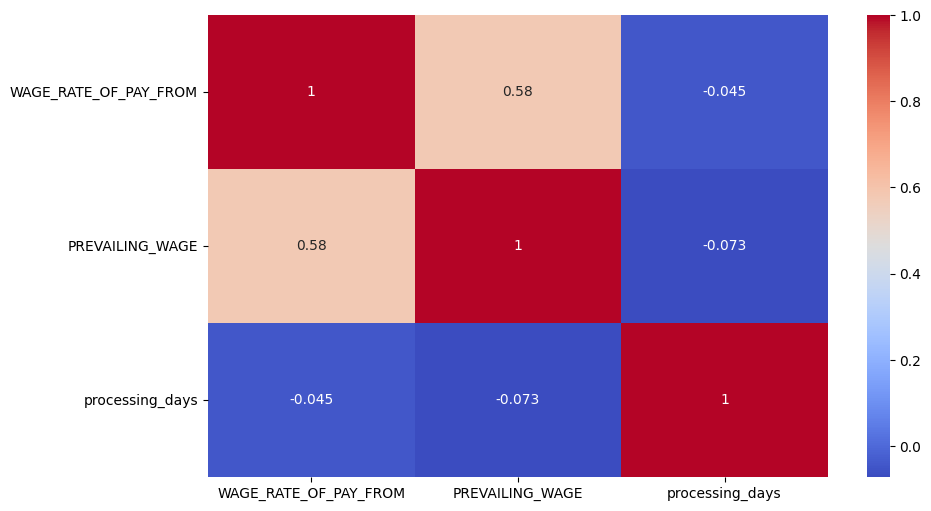

In [7]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6)) 
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
print("The correlation heatmap shows that most features have weak individual correlation with processing_days.\nThe strongest relationship is between CASE_STATUS and processing_days (0.36). \nAdditionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.")

The correlation heatmap shows that most features have weak individual correlation with processing_days.
The strongest relationship is between CASE_STATUS and processing_days (0.36). 
Additionally, WAGE_RATE_OF_PAY_FROM and PREVAILING_WAGE show strong correlation (0.58), indicating offered wages generally align with prevailing wage requirements.


In [9]:
df['wage_ratio'] = df['WAGE_RATE_OF_PAY_FROM'] / df['PREVAILING_WAGE']

In [10]:
df.head()

,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio
0,Certified,2021-09-26,2021-10-01,H-1B,APPLICATIONS SUPPORT ANALYST/ADMINISTRATOR,Y,NJ,GA,92000.0,87485.0,5,1.051609
1,Certified,2021-09-26,2021-10-01,H-1B,Designer,Y,MI,MI,56181.0,56181.0,5,1.000000
2,Certified,2021-09-26,2021-10-01,H-1B,Data Analyst,Y,FL,MA,60000.0,59238.0,5,1.012863
3,Certified,2021-09-26,2021-10-01,H-1B,Pharmaceutical Chemist,Y,MN,MN,56160.0,53851.0,5,1.042878
4,Certified,2021-09-26,2021-10-01,H-1B,Senior Systems Analyst JC60,Y,TX,TN,70325.0,70325.0,5,1.000000


In [12]:
df_dates = pd.read_csv("dataset.csv", low_memory=False)

df['application_month'] = pd.to_datetime(df_dates['RECEIVED_DATE']).dt.month

In [13]:
state_avg = df.groupby('EMPLOYER_STATE')['processing_days'].transform('mean')

df['state_processing_avg'] = state_avg

In [14]:
df.head()

,CASE_STATUS,RECEIVED_DATE,DECISION_DATE,VISA_CLASS,JOB_TITLE,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg
0,Certified,2021-09-26,2021-10-01,H-1B,APPLICATIONS SUPPORT ANALYST/ADMINISTRATOR,Y,NJ,GA,92000.0,87485.0,5,1.051609,9,16.459202
1,Certified,2021-09-26,2021-10-01,H-1B,Designer,Y,MI,MI,56181.0,56181.0,5,1.000000,9,40.323003
2,Certified,2021-09-26,2021-10-01,H-1B,Data Analyst,Y,FL,MA,60000.0,59238.0,5,1.012863,9,19.781505
3,Certified,2021-09-26,2021-10-01,H-1B,Pharmaceutical Chemist,Y,MN,MN,56160.0,53851.0,5,1.042878,9,23.065644
4,Certified,2021-09-26,2021-10-01,H-1B,Senior Systems Analyst JC60,Y,TX,TN,70325.0,70325.0,5,1.000000,9,23.650974


In [15]:
df['worksite_processing_avg'] = df.groupby('WORKSITE_STATE')['processing_days'].transform('mean')

df[['processing_days',
    'wage_ratio',
    'application_month',
    'state_processing_avg',
    'worksite_processing_avg']].corr()

,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
processing_days,1.000000,-0.002114,-0.063478,0.111452,0.084781
wage_ratio,-0.002114,1.000000,0.000417,-0.001567,-0.002536
application_month,-0.063478,0.000417,1.000000,-0.017125,-0.003883
state_processing_avg,0.111452,-0.001567,-0.017125,1.000000,0.431141
worksite_processing_avg,0.084781,-0.002536,-0.003883,0.431141,1.000000


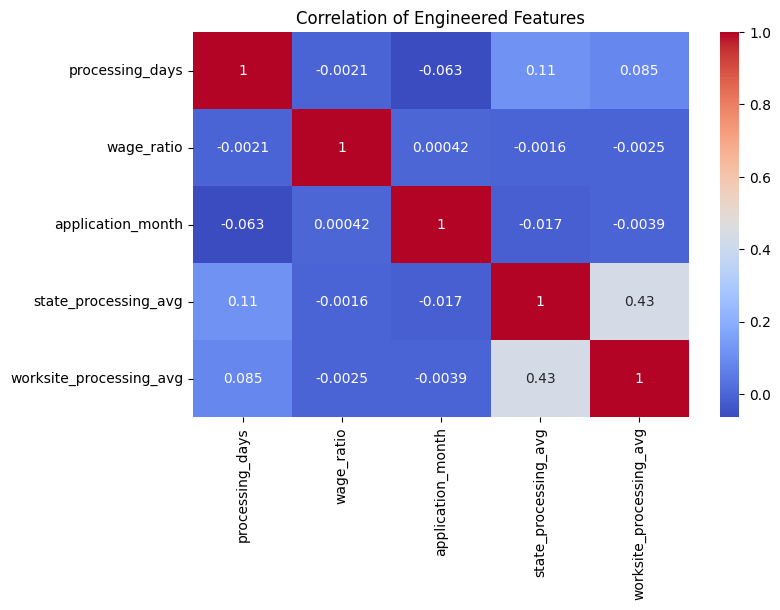

In [16]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['processing_days',
        'wage_ratio',
        'application_month',
        'state_processing_avg',
        'worksite_processing_avg']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation of Engineered Features")
plt.show()

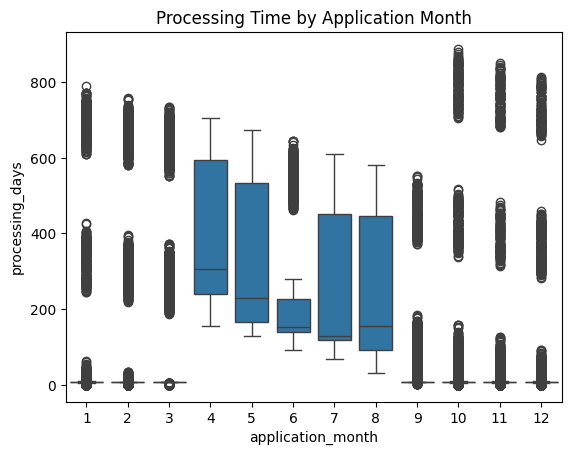

In [17]:
sns.boxplot(x='application_month', y='processing_days', data=df)

plt.title("Processing Time by Application Month")
plt.show()

In [18]:
print("The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) \nshow stronger correlation with processing time compared to wage-based features. \nThis suggests that geographic factors may influence visa processing duration more than salary-related attributes.")

The engineered features capturing regional processing trends (state_processing_avg and worksite_processing_avg) 
show stronger correlation with processing time compared to wage-based features. 
This suggests that geographic factors may influence visa processing duration more than salary-related attributes.


In [19]:
df.to_csv("cleaned_visa_feature_engineered_dataset.csv", index=False)
print("Milestone 2 Completed")

Milestone 2 Completed
